# 03 — From probabilities to cells

The network gives, for every pixel, the probability of being part of a cell. This notebook turns these probability maps into
individual cells, step by step, and explains each choice on the **validation images** (43 images the network was not
trained on; the test images are used only in notebook 04).

The adopted pipeline:

```
probability map → threshold 0.5 → fill holes → remove objects < 300 px
                → watershed (seeds at least 20 px apart): split touching cells
                → object classifier: drop objects that are probably not annotated cells
                → cells and their count
```


In [1]:
import json
import os
import sys
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy import ndimage
from skimage import measure
from skimage.feature import peak_local_max

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
from evaluation.metrics import overlap_tables
from evaluation.object_features import FEATURES
from evaluation.postprocess import label_instances, postprocess, predict_labels
from evaluation.predict import load_model, predict_probs
from evaluation.select_object_classifier import CANDIDATES, THRESHOLDS, object_prf, oof_scores
from evaluation.tune import bootstrap_diff, counts_row, metrics_from_counts
from evaluation.watershed_classifier import MIN_DISTANCE, PRED_MIN_AREA, THRESHOLD, delivered_labels
from train.dataset import GreenEvalDataset, load_img_and_masks, load_split
from train.split import count_from_coco

IMG_DIR = Path("data/green/trainval/images")
MASK_DIR = Path("data/cleaned_masks/trainval/Green/masks")
COCO = Path("data/green/trainval/ground_truths/COCO/annotations_green_trainval.json")
RUN = Path("runs/cresunet_light")

## 1. From the checkpoint to probability maps

The adopted network (c-ResUNet-light, `runs/cresunet_light/best.pt`, notebook 02) predicts the 43 validation images,
one full image at a time.

In [2]:
train_names, val_names = load_split(Path("splits/green_split.json"))
images, masks = load_img_and_masks(IMG_DIR, MASK_DIR, val_names)
true_masks = masks > 0

model, mean, std, epoch, norm = load_model(RUN / "best.pt", torch.device("cpu"))
dataset = GreenEvalDataset(images, masks, val_names, mean, std, norm=norm)
start = time.time()
probs, names = predict_probs(model, dataset, torch.device("cpu"))
probs = probs.astype(np.float32)
print(f"{len(probs)} probability maps in {time.time() - start:.0f} s (checkpoint of epoch {epoch})")

# check: the pixel Dice at threshold 0.5 is the validation Dice of the training log
predicted = probs > 0.5
dice = 2 * (predicted & true_masks).sum() / (predicted.sum() + true_masks.sum())
print(f"validation Dice at 0.5: {dice:.4f}")

43 probability maps in 143 s (checkpoint of epoch 78)
validation Dice at 0.5: 0.7622


## 2. Threshold: 0.5

A pixel is "cell" if its probability is above the threshold. The network is very confident: almost all probabilities are
close to 0 or to 1.

pixels with a probability between 0.1 and 0.9: 0.13%


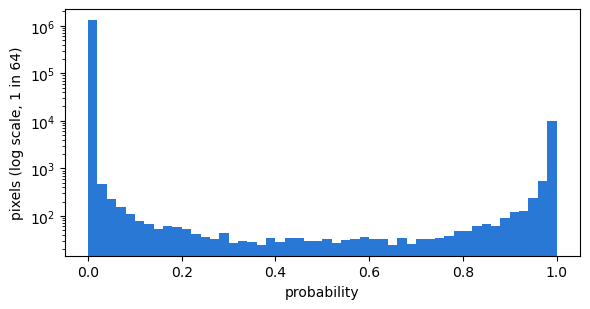

In [3]:
uncertain = (probs > 0.1) & (probs < 0.9)
print(f"pixels with a probability between 0.1 and 0.9: {100 * uncertain.mean():.2f}%")

plt.figure(figsize=(6, 3.2))
plt.hist(probs[::4, ::4, ::4].ravel(), bins=50, color="#2a78d6")
plt.yscale("log")
plt.xlabel("probability")
plt.ylabel("pixels (log scale, 1 in 64)")
plt.tight_layout()
plt.show()

So the exact threshold matters little. Object metrics for five thresholds (with the post-processing of section 3), and the
difference of the F1 from the threshold 0.5 with its 95% bootstrap interval over the images:

In [4]:
def network_counts(threshold):
    '''Per-image counts of the network + basic post-processing (no watershed, no classifier).'''
    rows = []
    for prob, true_mask in zip(probs, true_masks):
        labels = label_instances(postprocess(prob, threshold, PRED_MIN_AREA))
        rows.append(counts_row(labels, true_mask))
    return np.array(rows)

counts_by_threshold = {}
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    counts_by_threshold[threshold] = network_counts(threshold)

table = []
for threshold, counts in counts_by_threshold.items():
    metrics = metrics_from_counts(counts)
    low, high = bootstrap_diff(counts, counts_by_threshold[0.5], "obj_f1")
    table.append({"threshold": threshold, "Dice": metrics["dice"], "F1": metrics["obj_f1"],
                  "precision": metrics["obj_precision"], "recall": metrics["obj_recall"],
                  "F1 - F1(0.5), 95% CI": f"[{low:+.3f}, {high:+.3f}]"})
print(pd.DataFrame(table).round(3).to_string(index=False))

 threshold  Dice    F1  precision  recall F1 - F1(0.5), 95% CI
       0.3 0.764 0.806      0.764   0.852     [-0.005, +0.012]
       0.4 0.764 0.804      0.766   0.847     [-0.002, +0.006]
       0.5 0.764 0.803      0.766   0.844     [+0.000, +0.000]
       0.6 0.763 0.801      0.765   0.840     [-0.008, +0.002]
       0.7 0.763 0.802      0.770   0.837     [-0.007, +0.006]


No threshold is demonstrably better than 0.5 (every interval contains 0), so the natural value 0.5 is kept.

**How the object metrics work** (used in the whole notebook): the predicted mask is split into objects (connected
components); a predicted object and an annotated cell are a match if they overlap with IoU > 0.5. Matches are true
positives (TP); unmatched predicted objects are false positives (FP); unmatched annotated cells are false negatives (FN).
Precision = TP / predicted objects, recall = TP / annotated cells, F1 = their harmonic mean.

## 3. Filling holes and removing small objects

- **Fill holes:** c-FOS stains the nucleus, but the nucleolus inside often stays dark; a cell can become a ring. Holes are
  filled before anything else, so a ring counts as one full cell.
- **Remove objects smaller than 300 px.** The annotations were cleaned with a lower limit, 120 px (notebook 01: the smallest
  annotated cell has 126 px); for the predictions a higher limit is better, because small predicted objects are almost never
  cells.

The training images show it (objects predicted by the network + watershed on the 169 training images with the limit of the
labels, 120 px; "true" = matches an annotated cell):

In [5]:
objects_120 = pd.read_csv(RUN / "object_classifier_area120" / "objects_train.csv")   # one row per object, limit 120 px
bands = [120, 200, 300, 400, 600, 10_000]
for low, high in zip(bands[:-1], bands[1:]):
    in_band = objects_120[(objects_120.area >= low) & (objects_120.area < high)]
    print(f"area {low:5d}-{high:5d} px: {len(in_band):5d} objects, {100 * in_band.label.mean():5.1f}%")

area   120-  200 px:    60 objects,   0.0%
area   200-  300 px:    62 objects,   3.2%
area   300-  400 px:    89 objects,  31.5%
area   400-  600 px:   593 objects,  71.2%
area   600-10000 px:  2111 objects,  87.2%


Below 300 px almost no predicted object is an annotated cell (2 of 122). The limit was chosen in three steps, each on
different images:
1. **Training images.** Each limit (160–400 px) replaces 120 px in the complete pipeline (watershed and object classifier,
   sections 5–6). The object classifier is chosen again for each limit, and the F1 is estimated by a 5-fold
   cross-validation *of the classifier* on the training images: each object is judged by a classifier trained on the other
   images (out-of-fold F1).
2. **Validation images.** Only the limits that gain at least +0.005 of F1 in step 1 are checked on the 43 validation images;
   a limit is adopted only if the validation F1 improves demonstrably (95% interval above 0).
3. **Confirmation.** The adopted limit is checked again on all 212 trainval images with the 5-fold cross-validation *of the
   network* (5 networks, each image predicted by a network that did not see it; details in `experiments/`).

In [6]:
ablations = json.load(open(RUN / "postprocessing_ablations.json"))
rows = [{"min area (px)": 120, "out-of-fold F1": ablations["p_star"]["oof_f1"], "gain": 0.0, "validation: F1 difference, 95% CI": ""}]
for entry in ablations["grid"]:
    if entry["min_distance"] == MIN_DISTANCE:
        if "val_ci" in entry:
            low, high = entry["val_ci"]["obj_f1"]
            checked = f"[{low:+.4f}, {high:+.4f}]"
        else:
            checked = "not checked (gain < 0.005)"
        rows.append({"min area (px)": entry["min_area"], "out-of-fold F1": entry["oof_f1"], "gain": entry["gain"],
                     "validation: F1 difference, 95% CI": checked})
print(pd.DataFrame(rows).round(4).to_string(index=False))

cv = json.load(open("runs/cv_compare/results.json"))
low, high = cv["replication"]["ci95"]["obj_f1"]
per_fold = pd.read_csv("runs/cv_compare/per_fold.csv")
f1_120 = per_fold[per_fold.variant == "L + ws20 + clf"].set_index("fold").obj_f1
f1_300 = per_fold[per_fold.variant == "L + ws20 + a300 + clf"].set_index("fold").obj_f1
print(f"\ncross-validation (212 images), F1 with 300 px - with 120 px: 95% CI [{low:+.4f}, {high:+.4f}]; "
      f"better in {(f1_300 > f1_120).sum()} of 5 folds")

 min area (px)  out-of-fold F1   gain validation: F1 difference, 95% CI
           120          0.8343 0.0000                                  
           160          0.8367 0.0024        not checked (gain < 0.005)
           200          0.8376 0.0033        not checked (gain < 0.005)
           250          0.8387 0.0043        not checked (gain < 0.005)
           300          0.8407 0.0064                [+0.0013, +0.0085]
           350          0.8406 0.0063                [-0.0046, +0.0135]
           400          0.8400 0.0057                [-0.0093, +0.0140]

cross-validation (212 images), F1 with 300 px - with 120 px: 95% CI [+0.0008, +0.0092]; better in 5 of 5 folds


300 px is the smallest limit that passes: out of fold it gains +0.006 over 120 px, on the validation images the F1 improves
demonstrably, and the cross-validation on 212 images confirms the gain (+0.005, all five folds). The larger limits (350 and
400 px) do not improve the validation F1 demonstrably. The effect is small, because the object classifier (section 6), which
also uses the area, already drops most small objects.

## 4. The errors of the network alone

Before adding more steps, what kind of errors does the network (+ the steps above) make on the validation images?

In [7]:
def object_errors(predicted_labels, true_labels):
    '''Error types of one image: predicted objects (TP / FP), annotated cells (FN) and merges.'''
    inter, iou = overlap_tables(predicted_labels, true_labels)       # rows: predicted objects, columns: true cells
    errors = {"TP": 0, "FP isolated": 0, "FP partial": 0, "FN missed": 0, "FN partial": 0, "merged objects": 0}
    for i in range(inter.shape[0]):
        if (iou[i] > 0.5).any():
            errors["TP"] += 1
        elif inter[i].sum() == 0:
            errors["FP isolated"] += 1           # no annotated pixel under it
        else:
            errors["FP partial"] += 1            # touches a cell, but IoU <= 0.5
    for j in range(inter.shape[1]):
        if (iou[:, j] > 0.5).any():
            continue
        if inter[:, j].sum() == 0:
            errors["FN missed"] += 1             # no predicted pixel on it
        else:
            errors["FN partial"] += 1
    cell_area = np.bincount(true_labels.ravel(), minlength=inter.shape[1] + 1)[1:]
    for i in range(inter.shape[0]):
        if ((inter[i] / np.maximum(cell_area, 1)) > 0.5).sum() >= 2:
            errors["merged objects"] += 1        # covers more than half of two or more cells
    return errors

total = {}
for prob, true_mask in zip(probs, true_masks):
    errors = object_errors(label_instances(postprocess(prob, 0.5, PRED_MIN_AREA)), label_instances(true_mask))
    for key, value in errors.items():
        total[key] = total.get(key, 0) + value
print(total)

{'TP': 617, 'FP isolated': 168, 'FP partial': 21, 'FN missed': 81, 'FN partial': 33, 'merged objects': 12}


- **False positives:** most are *isolated* objects, with no annotated pixel under them, not pieces of real cells.
- **False negatives:** most annotated cells that are not found are *missed* completely, not segmented badly.
- **Merged objects:** a few predicted objects cover two touching cells (both cells are then lost).

Check if the isolated false positives and the missed cells are just noise ---> Their contrast (mean brightness of the object divided by
the median of its image) compared with the cells found correctly:

cells found (TP)          :  617 objects, median contrast 2.37
isolated false positives  :  168 objects, median contrast 1.95
missed cells              :   81 objects, median contrast 1.70


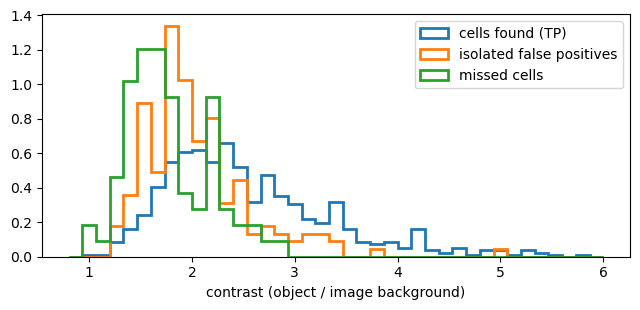

In [8]:
contrast = {"cells found (TP)": [], "isolated false positives": [], "missed cells": []}
for image, prob, true_mask in zip(images, probs, true_masks):
    green = image[..., 1].astype(np.float32)
    background = np.median(green)
    predicted_labels = label_instances(postprocess(prob, 0.5, PRED_MIN_AREA))
    true_labels = label_instances(true_mask)
    inter, iou = overlap_tables(predicted_labels, true_labels)
    for region in measure.regionprops(predicted_labels, intensity_image=green):
        i = region.label - 1
        if (iou[i] > 0.5).any():
            contrast["cells found (TP)"].append(region.intensity_mean / background)
        elif inter[i].sum() == 0:
            contrast["isolated false positives"].append(region.intensity_mean / background)
    for region in measure.regionprops(true_labels, intensity_image=green):
        if inter[:, region.label - 1].sum() == 0:
            contrast["missed cells"].append(region.intensity_mean / background)

for group, values in contrast.items():
    print(f"{group:26s}: {len(values):4d} objects, median contrast {np.median(values):.2f}")

plt.figure(figsize=(6.5, 3.2))
for group, values in contrast.items():
    plt.hist(values, bins=np.linspace(0.8, 6, 40), histtype="step", linewidth=2, density=True, label=group)
plt.xlabel("contrast (object / image background)")
plt.legend()
plt.tight_layout()
plt.show()

The three groups overlap a lot. The isolated false positives look like real cells, only somewhat fainter; the missed cells
are the faintest annotated ones. The annotation protocol of the dataset asks annotators to be conservative with doubtful,
faint cells, and the decision is subjective. So many "errors" are faint cells where the labels themselves are ambiguous:
a limit that no post-processing can fully remove. The two next steps attack what *can* be fixed: merged cells (section 5)
and objects that do not look like annotated cells (section 6).

## 5. Watershed: splitting touching cells

When two cells touch, the predicted mask joins them into one object. The watershed splits such objects using their shape:

1. **distance transform:** every pixel of an object gets its distance from the background; the centre of each cell is a peak;
2. **seeds:** the peaks that are at least **20 px** apart;
3. **watershed:** each pixel of the object is assigned to the closest seed, following the "valleys" of the distance map.

An example from the validation images:

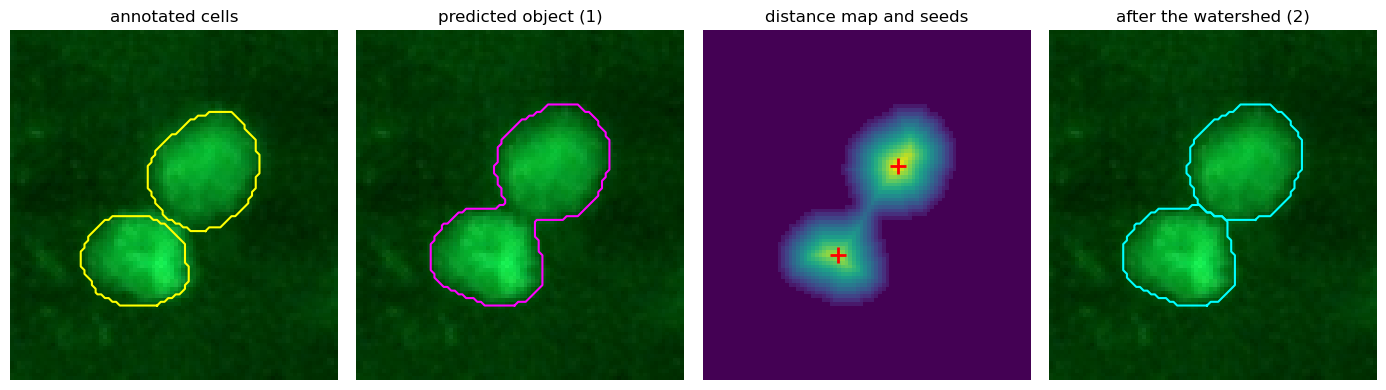

In [9]:
def outline(ax, mask, color):
    for contour in measure.find_contours(np.asarray(mask) > 0, 0.5):
        ax.plot(contour[:, 1], contour[:, 0], color=color, linewidth=1.5)

# find a predicted object that covers two cells and is split by the watershed
example = None
for i, (prob, true_mask) in enumerate(zip(probs, true_masks)):
    before = label_instances(postprocess(prob, 0.5, PRED_MIN_AREA))
    after = predict_labels(prob, 0.5, min_distance=MIN_DISTANCE, min_area=PRED_MIN_AREA)
    true_labels = label_instances(true_mask)
    for region in measure.regionprops(before):
        cells_under = np.unique(true_labels[before == region.label])
        pieces_after = np.unique(after[before == region.label])
        if len(cells_under[cells_under > 0]) >= 2 and len(pieces_after[pieces_after > 0]) >= 2:
            example = (i, region)
            break
    if example is not None:
        break

i, region = example
r0, c0, r1, c1 = region.bbox
r0, c0, r1, c1 = max(r0 - 20, 0), max(c0 - 20, 0), r1 + 20, c1 + 20
crop_image = np.clip(images[i][r0:r1, c0:c1] / 150, 0, 1)
crop_object = before[r0:r1, c0:c1] == region.label
distance = ndimage.distance_transform_edt(crop_object)
seeds = peak_local_max(distance, min_distance=MIN_DISTANCE, labels=crop_object.astype(int))
crop_after = after[r0:r1, c0:c1] * crop_object

fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
axes[0].imshow(crop_image)
outline(axes[0], true_masks[i][r0:r1, c0:c1], "yellow")
axes[0].set_title("annotated cells")
axes[1].imshow(crop_image)
outline(axes[1], crop_object, "magenta")
axes[1].set_title("predicted object (1)")
axes[2].imshow(distance, cmap="viridis")
axes[2].plot(seeds[:, 1], seeds[:, 0], "r+", markersize=12, markeredgewidth=2)
axes[2].set_title("distance map and seeds")
axes[3].imshow(crop_image)
for piece in np.unique(crop_after[crop_after > 0]):
    outline(axes[3], crop_after == piece, "cyan")
axes[3].set_title(f"after the watershed ({len(seeds)})")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

**Why seeds at least 20 px apart.** A cell has a radius of ~15 px, so two touching cells have their centres ~30 px apart and
are split; one cell with an irregular shape rarely has two peaks 20 px apart, so it is not cut in two. Several distances
were compared on the **training images**, one change at a time (with the limit of the labels, 120 px): merged objects, single
cells cut into pieces, and the out-of-fold F1 of the whole pipeline with the object classifier chosen again for each distance:

In [10]:
p_star = ablations["p_star"]                                  # the pipeline with seeds 20 px apart
grid = {entry["min_distance"]: entry for entry in ablations["grid"] if entry["min_area"] == 120}
grid[20] = {"merged": p_star["merged_train"], "split_cells": p_star["split_cells_train"], "oof_f1": p_star["oof_f1"]}

rows = []
for distance in ["none", 12, 15, 20, 25]:
    rows.append({"seeds at least (px)": distance, "merged objects": grid[distance]["merged"],
                 "single cells cut in two": grid[distance]["split_cells"], "out-of-fold F1": grid[distance]["oof_f1"]})
print(pd.DataFrame(rows).round(4).to_string(index=False))

seeds at least (px)  merged objects  single cells cut in two  out-of-fold F1
               none              28                        0          0.8322
                 12              15                        3          0.8379
                 15              19                        1          0.8355
                 20              23                        0          0.8343
                 25              27                        0          0.8327


At 12 and 15 px the watershed already cuts some single cells in two (3 and 1); at 20 px it cuts none and still removes about
a fifth of the merges (28 → 23 on the training images); at 25 px it separates almost none (27 merges remain). 12 px has a slightly higher
out-of-fold F1 (+0.004), below the gain required to change a choice (+0.005), and it cuts cells. The watershed at 20 px was
also checked with the **5-fold cross-validation** on all 212 trainval images (5 networks trained with the same recipe, each
image predicted by a network that did not see it; details in `experiments/`):

In [11]:
cv = json.load(open("runs/cv_compare/results.json"))
low, high = cv["descriptive"]["L + ws20 + clf − L + clf"]["obj_f1"]
per_fold = pd.read_csv("runs/cv_compare/per_fold.csv")
f1_without = per_fold[per_fold.variant == "L + clf"].set_index("fold").obj_f1
f1_with = per_fold[per_fold.variant == "L + ws20 + clf"].set_index("fold").obj_f1
print(f"F1 with - without the watershed (212 images): 95% CI [{low:+.4f}, {high:+.4f}]")
print(f"folds where the watershed improves the F1: {(f1_with > f1_without).sum()} of 5")

F1 with - without the watershed (212 images): 95% CI [+0.0015, +0.0096]
folds where the watershed improves the F1: 4 of 5


A small improvement, in 4 of the 5 folds and demonstrable on the 212 images together: the watershed at 20 px is part of
the adopted pipeline.

## 6. The object classifier

After the watershed, every predicted object is described by 10 numbers, and a classifier estimates the probability that it
is an annotated cell. Objects with a low probability are dropped.

| feature | meaning |
|---|---|
| `area` | size in pixels |
| `mean_prob` | mean probability of the network inside the object (how sure the network is) |
| `contrast` | mean brightness of the object / median brightness of its image |
| `rel_contrast` | contrast / median contrast of the objects of the same image (bright compared with the other cells?) |
| `local_bg` | brightness of a 10 px ring around the object / image median |
| `solidity` | area / area of the convex hull (1 = convex, low = irregular shape) |
| `eccentricity` | 0 = circle, close to 1 = elongated |
| `nn_dist` | distance to the closest other object |
| `n_objects` | number of objects in the image |
| `intensity` | absolute mean brightness |

Several of them describe the **whole image** (relative contrast, number of objects), something the network cannot see
(its window is ~96 px).

**Training data:** the objects that the network + watershed (limit 300 px) predict on the **169 training images**, each
labelled "true" if
it matches an annotated cell (IoU > 0.5).

In [12]:
objects = pd.read_csv(RUN / "object_classifier" / "objects_train.csv")
print(f"{len(objects)} objects on the training images, {objects.label.sum()} true ({100 * objects.label.mean():.0f}%)")

on_border = objects[objects.border]
inside = objects[~objects.border]
print(f"objects touching the image border: {len(on_border)}, true: {100 * on_border.label.mean():.0f}%")
print(f"objects inside the image:          {len(inside)}, true: {100 * inside.label.mean():.0f}%")

2793 objects on the training images, 2291 true (82%)
objects touching the image border: 84, true: 31%
objects inside the image:          2709, true: 84%


**Objects touching the image border are never judged by the classifier (always kept).** On the border, the objects found by
the network rarely have a counterpart in the annotations: here 31% of them match an annotated cell, against 84% inside the
image. Most of them look like nuclei cut by the image border (section 8), but some could be artefacts; the annotation protocol
does not mention this case, and we do not know whether it is intended. A classifier trained on all objects could learn this
pattern through the size and shape of the cut objects, i.e. remove objects because they are cut rather than because they do
not look like cells. The classifier is therefore trained only on the interior objects and never removes border objects: they
are kept or removed by the network and by the rules that apply to every object (threshold, minimum area of 300 px, watershed).

**Choosing the classifier.** Two models (logistic regression and gradient boosting) and the probability threshold were
chosen with a 5-fold cross-validation on the training objects, grouped by image (all objects of an image in the same fold):
each object gets a score from a model trained on the other folds, and the F1 is computed for every threshold.

logistic : best threshold 0.34, out-of-fold F1 0.8407
boosting : best threshold 0.09, out-of-fold F1 0.8369


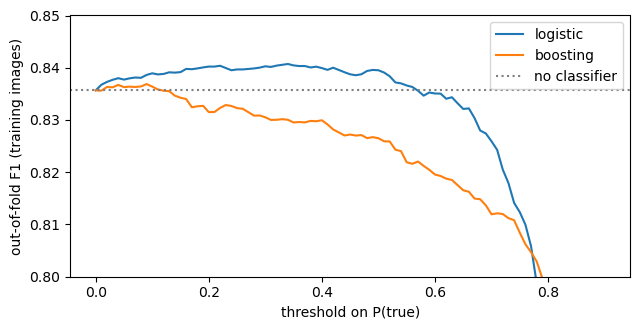

In [13]:
n_true_train = sum(count_from_coco(IMG_DIR, COCO)[2][name] for name in train_names)   # annotated cells in the training images

curves = {}
for name in ["logistic", "boosting"]:
    scores = oof_scores(CANDIDATES[name], objects, 5)         # out-of-fold P(true); border objects get 1
    curves[name] = [object_prf(objects, n_true_train, scores >= t)["obj_f1"] for t in THRESHOLDS]
    best = int(np.argmax(curves[name]))
    print(f"{name:9s}: best threshold {THRESHOLDS[best]:.2f}, out-of-fold F1 {curves[name][best]:.4f}")

plt.figure(figsize=(6.5, 3.4))
for name, f1 in curves.items():
    plt.plot(THRESHOLDS, f1, label=name)
plt.axhline(curves["logistic"][0], color="grey", linestyle=":", label="no classifier")
plt.ylim(0.80, 0.85)
plt.xlabel("threshold on P(true)")
plt.ylabel("out-of-fold F1 (training images)")
plt.legend()
plt.tight_layout()
plt.show()

The logistic regression has the highest out-of-fold F1 (0.8407, against 0.8369 for gradient boosting and 0.8357 without
classifier), and it is also the simpler model, with weights that can be read. Objects with P(true) below 0.34 are dropped. The classifier trained on
all training objects is saved once (`classifier.joblib`) and used as it is on the validation and test images. Its weights
(on standardized features: the sign says in which direction the feature pushes towards "true"):

In [14]:
classifier = joblib.load(RUN / "object_classifier" / "classifier.joblib")
weights = pd.Series(classifier[-1].coef_[0], index=FEATURES)
print(weights.sort_values(key=abs, ascending=False).round(2).to_string())
print("threshold on P(true):", THRESHOLD)

rel_contrast    1.08
mean_prob       0.77
local_bg       -0.31
area           -0.26
solidity        0.23
n_objects      -0.21
eccentricity    0.14
nn_dist        -0.13
contrast       -0.10
intensity      -0.07
threshold on P(true): 0.34


The strongest signals are the contrast relative to the other objects of the same image (`rel_contrast`) and the confidence
of the network (`mean_prob`); a bright local background (`local_bg`) and a large area push towards "not a cell".

## 7. The adopted pipeline on the validation images

The three versions of the pipeline on the same 43 validation images, adding one step at a time. `delivered_labels` is the
function that runs the whole adopted pipeline on one image (the same function is used on the test images).

In [15]:
rows_network, rows_watershed, rows_adopted = [], [], []
labels_watershed, tables = [], []
for i in range(len(val_names)):
    true_labels = label_instances(true_masks[i])
    rows_network.append(counts_row(label_instances(postprocess(probs[i], 0.5, PRED_MIN_AREA)), true_masks[i]))
    after_watershed = predict_labels(probs[i], 0.5, min_distance=MIN_DISTANCE, min_area=PRED_MIN_AREA)
    rows_watershed.append(counts_row(after_watershed, true_masks[i]))
    final_labels, table = delivered_labels(probs[i], images[i], true_labels, i, classifier)
    rows_adopted.append(counts_row(final_labels, true_masks[i]))
    labels_watershed.append(after_watershed)
    tables.append(table)

versions = {"network only": np.array(rows_network),
            "+ watershed": np.array(rows_watershed),
            "+ watershed + classifier (adopted)": np.array(rows_adopted)}
summary = []
for name, counts in versions.items():
    metrics = metrics_from_counts(counts)
    summary.append({"pipeline": name, "Dice": metrics["dice"], "F1": metrics["obj_f1"],
                    "precision": metrics["obj_precision"], "recall": metrics["obj_recall"],
                    "merged": metrics["n_merged"], "count MAE": metrics["count_mae"], "count bias": metrics["count_bias"]})
print(pd.DataFrame(summary).round(3).to_string(index=False))

print('\n\n')

adopted = metrics_from_counts(versions["+ watershed + classifier (adopted)"])

for metric in ["obj_f1", "obj_precision", "obj_recall", "dice", "count_mae"]:
    low, high = bootstrap_diff(versions["+ watershed + classifier (adopted)"], versions["network only"], metric)
    print(f"adopted - network only, {metric:13s}: 95% CI [{low:+.3f}, {high:+.3f}]")

                          pipeline  Dice    F1  precision  recall  merged  count MAE  count bias
                      network only 0.764 0.803      0.766   0.844      12      4.442       1.744
                       + watershed 0.764 0.811      0.771   0.855       9      4.465       1.860
+ watershed + classifier (adopted) 0.761 0.815      0.790   0.841       9      4.395       1.093



adopted - network only, obj_f1       : 95% CI [+0.003, +0.023]
adopted - network only, obj_precision: 95% CI [+0.016, +0.036]
adopted - network only, obj_recall   : 95% CI [-0.016, +0.012]
adopted - network only, dice         : 95% CI [-0.009, +0.004]
adopted - network only, count_mae    : 95% CI [-0.419, +0.349]


- The **watershed** splits merged cells: fewer merges (12 → 9) and a higher recall (0.844 → 0.855).
- The **classifier** removes objects that are not annotated cells: a clearly higher precision (0.771 → 0.790), for a small
  loss of recall, and a count bias closer to 0 (+1.9 → +1.1 cells per image).
- Together the F1 goes from 0.803 to 0.815, demonstrably (the interval is above 0); the pixel Dice does not change
  demonstrably.

## 8. What the classifier drops, and what it keeps

Crops of 80 × 80 px around some validation objects: the predicted object in magenta, the annotated cells in yellow.

dropped by the classifier: 33 | kept but not matching an annotated cell: 144


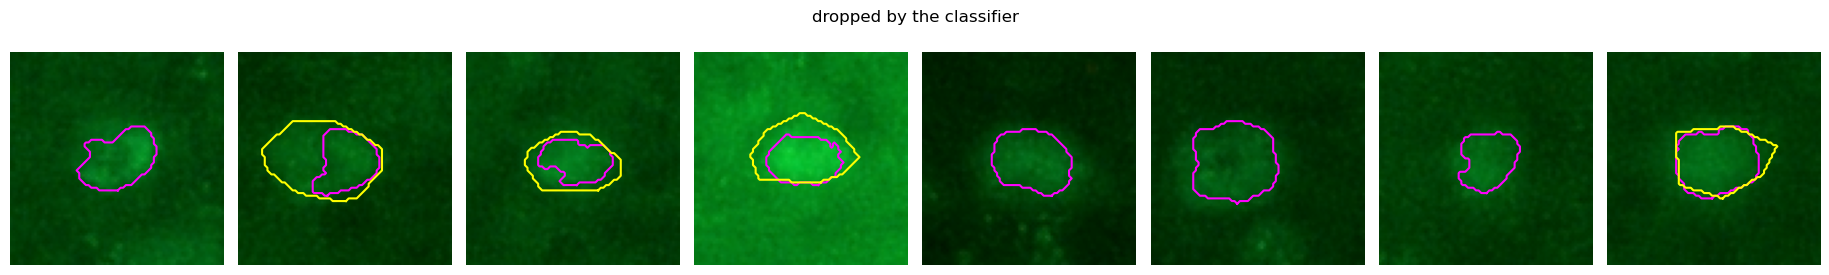

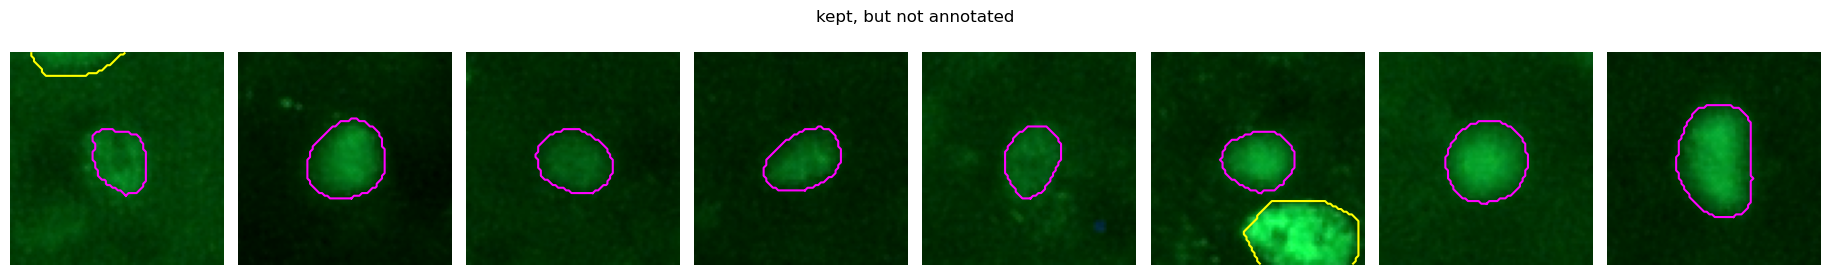

In [16]:
def show_objects(selected, title):
    '''Crops around some objects: predicted object in magenta, annotated cells in yellow.'''
    fig, axes = plt.subplots(1, len(selected), figsize=(2.3 * len(selected), 2.8))
    for ax, (i, obj) in zip(axes, selected):
        r, c = measure.regionprops((labels_watershed[i] == obj).astype(int))[0].centroid
        r0 = int(min(max(r - 40, 0), 1200 - 80))
        c0 = int(min(max(c - 40, 0), 1600 - 80))
        ax.imshow(np.clip(images[i][r0:r0 + 80, c0:c0 + 80] / 150, 0, 1))
        outline(ax, labels_watershed[i][r0:r0 + 80, c0:c0 + 80] == obj, "magenta")
        outline(ax, true_masks[i][r0:r0 + 80, c0:c0 + 80], "yellow")
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

dropped, kept_false = [], []
for i, table in enumerate(tables):
    for _, row in table.iterrows():
        if not row.keep:
            dropped.append((i, int(row.obj)))
        elif row.label == 0 and not row.border:
            kept_false.append((i, int(row.obj)))
print(f"dropped by the classifier: {len(dropped)} | kept but not matching an annotated cell: {len(kept_false)}")

rng = np.random.default_rng(0)
show_objects([dropped[k] for k in rng.choice(len(dropped), 8, replace=False)], "dropped by the classifier")
show_objects([kept_false[k] for k in rng.choice(len(kept_false), 8, replace=False)], "kept, but not annotated")

objects on the image border not matching an annotated cell (always kept): 19


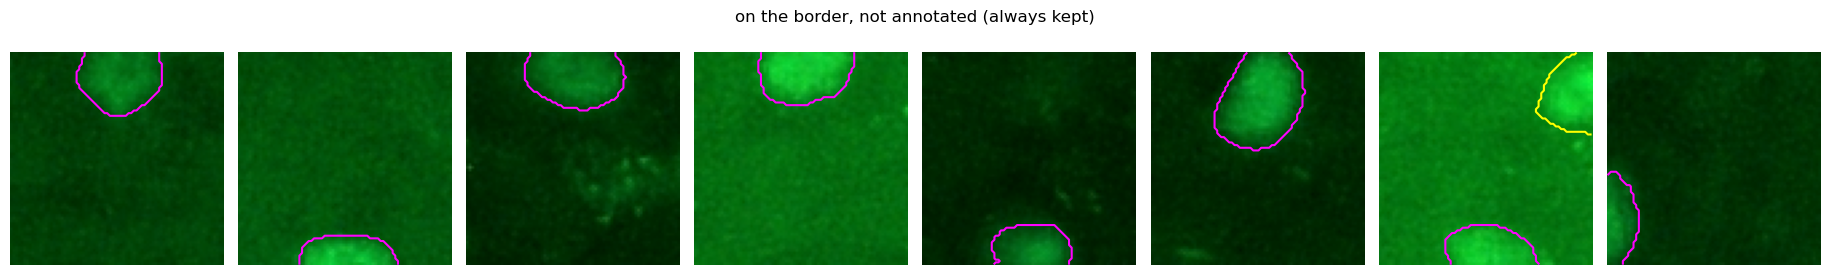

In [17]:
on_border = []
for i, table in enumerate(tables):
    for _, row in table.iterrows():
        if row.border and row.label == 0:
            on_border.append((i, int(row.obj)))
print(f"objects on the image border not matching an annotated cell (always kept): {len(on_border)}")
show_objects([on_border[k] for k in rng.choice(len(on_border), 8, replace=False)], "on the border, not annotated (always kept)")

- **Dropped** (33 objects, 23 of them not annotated cells): smaller and fainter than the other objects of the same image, and
  less certain for the network (median area 443 vs 766 px, relative contrast 0.84 vs 1.00, mean probability 0.89 vs 0.98);
  some are partial outlines of annotated cells, which would not match them with IoU > 0.5.
- **Kept but not annotated:** mostly round, well-formed objects that look like cells, often somewhat fainter: plausible
  cells that the annotators left out. No feature separates them from the annotated cells: this is the ambiguity of the
  labels seen in section 4, and it is the main limit of the pipeline.
- **On the border, not annotated** (19 objects, always kept, section 6): mostly round, uniformly stained objects cut by the
  image border, with the appearance of the annotated nuclei; a few are fainter.

## 9. Tried and not adopted

Other post-processing ideas, each tested by changing one element of the pipeline (with the object classifier chosen again
for each variant). Same decision rule as for every choice: an out-of-fold gain of at least +0.005 on the training images,
then a demonstrable F1 improvement on the validation images. Details in `experiments/`.

| idea | result | decision |
|---|---|---|
| other probability thresholds (0.3–0.7) | no difference (section 2) | 0.5 kept |
| minimum area 160, 200 or 250 px | out-of-fold gain +0.002 to +0.004 | below the required gain |
| minimum area 350 or 400 px | out-of-fold gain +0.006; validation F1 [−0.005, +0.013] and [−0.009, +0.014] | not adopted: no demonstrable gain |
| watershed with seeds 12 or 15 px apart | out-of-fold gain +0.004 and +0.001; 3 and 1 single cells cut in two | below the required gain: 20 px kept (section 5) |
| test-time augmentation (average of the 8 flips/rotations) | network alone on the training images: F1 +0.0048 | below the required gain |
| morphological closing (to repair fragmented cells) | pairs of predicted objects within 6 px on the training images: 1 from the same cell, 18 from different cells, 4 with an unannotated object | not adopted: it would mostly join different cells |
| more features from the annotation protocol (roundness, dark nucleoli, edge sharpness, size, texture) | out-of-fold F1 −0.00004 | not adopted: redundant with the existing features |
| adding candidate cells found by other methods (robust threshold, Cellpose) with a second classifier | out-of-fold gain at most +0.0002 | not adopted: the added candidates are mostly false |

## 10. Summary

```
probability map (c-ResUNet-light, epoch 78)
  → threshold 0.5 → fill holes → remove objects < 300 px
  → watershed, seeds at least 20 px apart
  → object classifier: logistic regression on 10 features, keep if P(true) ≥ 0.34 (border objects always kept)
```

On the validation images: F1 0.815 (precision 0.790, recall 0.841), Dice 0.761, 9 merged objects, ~4 cells of counting error
per image. Notebook 04 applies exactly this pipeline to the test images.